In [16]:
import numpy as np 
import pandas as pd 

import seaborn as sns 
import matplotlib.pyplot as plt


In [2]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')


In [13]:
df_test_open[['pred_winner', 'num_wins_red', 'num_wins_blue', 'num_losses_red', 'num_losses_blue', 'proba_red']]

,pred_winner,num_wins_red,num_wins_blue,num_losses_red,num_losses_blue,proba_red
0,0,6.0,8.0,4.0,2.0,0.431514
1,0,3.0,1.0,0.0,0.0,0.422921
2,1,1.0,7.0,1.0,3.0,0.841634
3,0,1.0,0.0,2.0,1.0,0.470522
4,1,8.0,2.0,2.0,3.0,0.792464
...,...,...,...,...,...,...
622,1,1.0,0.0,0.0,2.0,0.815156
623,0,16.0,9.0,7.0,2.0,0.121191
624,1,8.0,1.0,6.0,1.0,0.528892
625,0,5.0,1.0,4.0,2.0,0.306611


In [ ]:

def obs_per_fighter(df_test): 

    dat = []
    for _, row in df_test.iterrows():

        pred_winner = row['pred_winner'] == 1
        if pred_winner: 
            total_fights = row['num_wins_red'] + row['num_losses_red']
        else: 
            total_fights = row['num_wins_blue'] + row['num_losses_blue']

        choice_proba = row['proba_red'] if pred_winner == 1 else row['proba_blue']
        new_row = [pred_winner, choice_proba, row['winner'],  total_fights]
        dat.append(new_row)
    
    return pd.DataFrame(dat, columns=['pred_winner', 'choice_proba', 'winner', 'total_fights'])

df_total_fights = obs_per_fighter(df_test_open)

<Axes: xlabel='total_fights', ylabel='Count'>

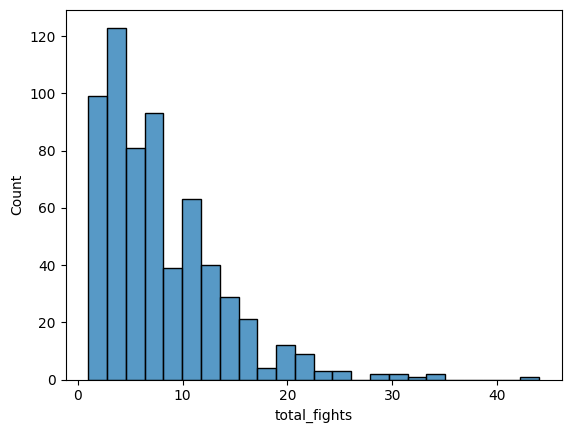

In [17]:
sns.histplot(df_total_fights['total_fights'])

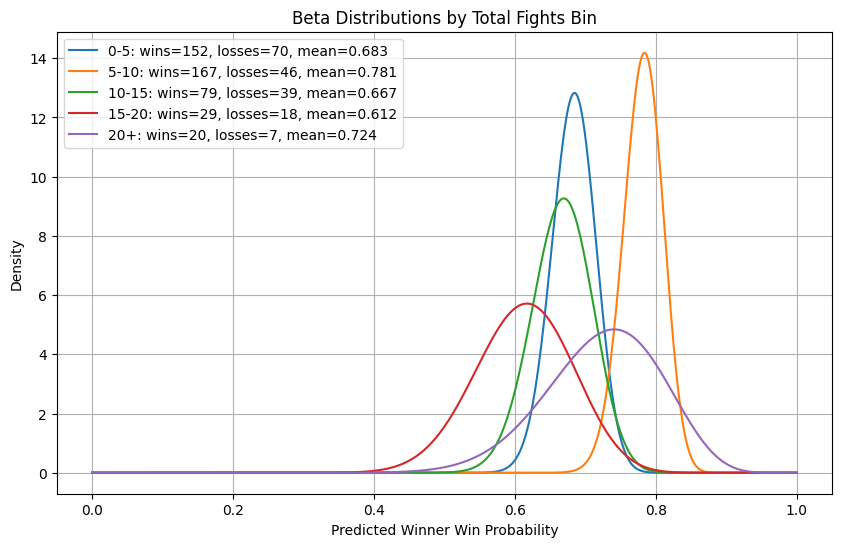

In [ ]:
from scipy.stats import beta
df = df_total_fights.copy()

# bin total fights: 0-5, 5-10, 10-15, 15-20, 20+
bins = [0, 5, 10, 15, 20, np.inf]
labels = ["0-5", "5-10", "10-15", "15-20", "20+"]

df["fight_bin"] = pd.cut(
    df["total_fights"],
    bins=bins,
    labels=labels,
    right=False
)

# did predicted winner actually win?
df["pred_correct"] = df["pred_winner"] == df["winner"]

x = np.linspace(0, 1, 500)

plt.figure(figsize=(10, 6))

for fight_bin, group in df.groupby("fight_bin", observed=True):

    wins = group["pred_correct"].sum()
    losses = len(group) - wins

    # Beta posterior with uniform prior Beta(1, 1)
    a = wins + 1
    b = losses + 1

    y = beta.pdf(x, a, b)

    mean_prob = a / (a + b)

    plt.plot(
        x,
        y,
        label=(
            f"{fight_bin}: "
            f"wins={wins}, "
            f"losses={losses}, "
            f"mean={mean_prob:.3f}"
        )
    )
 